In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from transformers import DistilBertTokenizer, TFDistilBertForSequenceClassification

Loading and preprocessing the dataset

In [ ]:
DATA_PATH = "../datasets/customer_support_large_dataset.csv"

df = pd.read_csv(DATA_PATH)
df = df[['query_text', 'category']].dropna()
df['query_text'] = df['query_text'].astype(str).str.strip()
df['category'] = df['category'].astype(str).str.strip()

# Encode labels first so we can stratify later
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['category'])

# Find smallest class size
min_count = df['label'].value_counts().min()

# Downsample each class to min_count
df_balanced = (
    df.groupby('label', group_keys=False)
      .apply(lambda x: x.sample(min_count, random_state=42))
      .reset_index(drop=True)
)

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Mapping:", label_mapping)

num_labels = len(label_encoder.classes_)
print(f"Balanced dataset size: {len(df_balanced)}, Classes: {num_labels}")
print(df_balanced['label'].value_counts())

Label Mapping: {'cancel_order': np.int64(0), 'demand_refund': np.int64(1), 'goodbye': np.int64(2), 'greeting': np.int64(3), 'order_status': np.int64(4), 'order_tracking': np.int64(5), 'out_of_scope': np.int64(6), 'payment_issue': np.int64(7), 'review_order': np.int64(8), 'submit_complaint': np.int64(9), 'talk_to_human': np.int64(10)}
Balanced dataset size: 4598, Classes: 11
label
0     418
1     418
2     418
3     418
4     418
5     418
6     418
7     418
8     418
9     418
10    418
Name: count, dtype: int64


/tmp/ipython-input-163537730.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min_count, random_state=42))


Splitting between training and testing data

In [5]:
train_df, temp_df = train_test_split(df_balanced, test_size=0.3, stratify=df_balanced['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 3218, Val: 690, Test: 690


Tokenizing the dataset and preparing the model for training

In [6]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 2

tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)

def tokenize_dataset(texts, labels):
    enc = tokenizer(
        texts.tolist(),
        max_length=MAX_LEN,
        padding="max_length",
        truncation=True,
        return_tensors="tf"
    )
    dataset = tf.data.Dataset.from_tensor_slices((
        dict(enc),
        labels
    ))
    return dataset

train_ds = tokenize_dataset(train_df['query_text'], train_df['label']).shuffle(500).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = tokenize_dataset(val_df['query_text'], val_df['label']).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = tokenize_dataset(test_df['query_text'], test_df['label']).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Initializing the model
with tf.device('/GPU:0'):
    model = TFDistilBertForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        from_pt=True  # Load PyTorch weights into TF
    )

optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
metrics = [tf.keras.metrics.SparseCategoricalAccuracy("accuracy")]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


pytorch_model.bin:   0%|          | 0.00/268M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_transform.bias', 'vocab_projector.weight', 'vocab_layer_norm.weight', 'vocab_transform.weight', 'vocab_projector.bias', 'vocab_layer_norm.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSeq

Train the model and draw plots

Epoch 1/2
202/202 [==============================] - 88s 242ms/step - loss: 0.4678 - accuracy: 0.9319 - val_loss: 0.0186 - val_accuracy: 1.0000
Epoch 2/2
202/202 [==============================] - 46s 227ms/step - loss: 0.0130 - accuracy: 1.0000 - val_loss: 0.0049 - val_accuracy: 1.0000


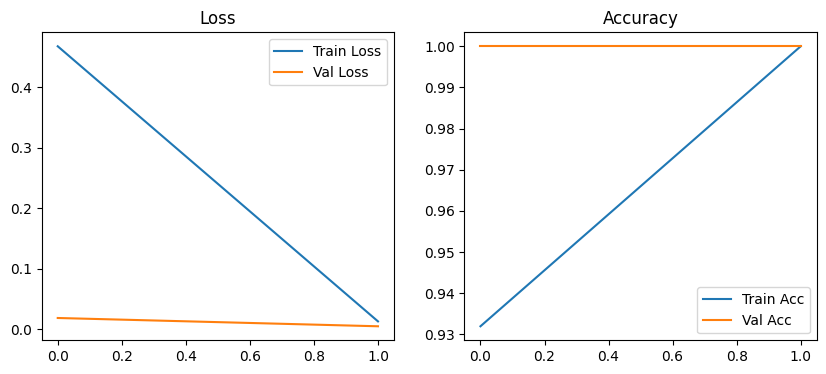

In [7]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

# PLotting loss and accuracy
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")
plt.show()

Evaluation metrics

Test evaluation:
44/44 [==============================] - 6s 74ms/step

Classification Report:
                  precision    recall  f1-score   support

    cancel_order       1.00      1.00      1.00        62
   demand_refund       1.00      1.00      1.00        62
         goodbye       1.00      1.00      1.00        63
        greeting       1.00      1.00      1.00        63
    order_status       1.00      1.00      1.00        63
  order_tracking       1.00      1.00      1.00        63
    out_of_scope       1.00      1.00      1.00        63
   payment_issue       1.00      1.00      1.00        63
    review_order       1.00      1.00      1.00        63
submit_complaint       1.00      1.00      1.00        63
   talk_to_human       1.00      1.00      1.00        62

        accuracy                           1.00       690
       macro avg       1.00      1.00      1.00       690
    weighted avg       1.00      1.00      1.00       690



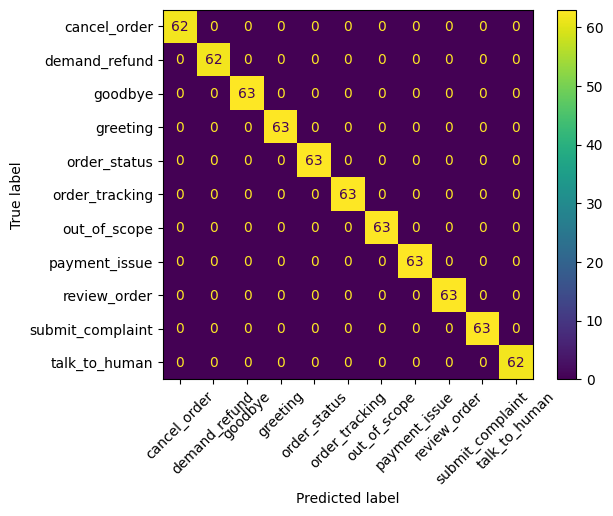

In [8]:

print("Test evaluation:")
results = model.evaluate(test_ds)

preds = model.predict(test_ds).logits
y_pred = np.argmax(preds, axis=1)
y_true = test_df['label'].to_numpy()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=label_encoder.classes_)
disp.plot(xticks_rotation=45)
plt.show()

Sample Data Test

In [14]:
sample_text = "hello"
tokens = tokenizer(sample_text, max_length=MAX_LEN, padding="max_length", truncation=True, return_tensors="tf")
output = model(tokens)
pred_label = np.argmax(output.logits, axis=1)[0]
print("Predicted intent:", label_encoder.inverse_transform([pred_label])[0])

Predicted intent: greeting


Saving the finetuned models

In [ ]:
model.save_pretrained("./intent_classification_model")
tokenizer.save_pretrained("./intent_classification_model")

  adding: intent_classification_model/ (stored 0%)
  adding: intent_classification_model/config.json (deflated 56%)
  adding: intent_classification_model/special_tokens_map.json (deflated 42%)
  adding: intent_classification_model/tokenizer_config.json (deflated 75%)
  adding: intent_classification_model/tf_model.h5 (deflated 8%)
  adding: intent_classification_model/vocab.txt (deflated 53%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>